# Awkward Array

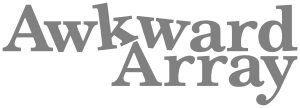

## **What is Awkward Array?**

Awkward Array is a popular Python library that is used to manipulate complex, nested, and variable-sized data using NumPy-like syntax and performance. 

## **Why is it named "Awkward"?**

Computational tools such as Numpy and Pandas strictly expect the data to be tabular (e.g. N x M grids); every row has exactly the same number of columns. However, real-world data often does not fit this expectation, meaning data can be awkward in nature. Some examples of real-world examples include tracking particle collisions in physics or recording transcripts per gene in biology. Awkward Array allows arrays whose elements can have different lengths (jagged/ragged data), while still supporting vectorized operations.

To deal with "awkward" real-data without using Awkward Arrays, you can still use standard Python lists. The caveat with using standard lists is that while they can be highly flexible, it can end up being really slow and memory-heavy. Awkward Arrays overcome this limitation as it allows fast, memory-reduced operations on complex data while writing clean NumPy-style code.

## **First Steps with Awkward Array**

Imagine you are working with particle physics data, where events and particles in each event is recorded. 

To deal with this data computationally, you can think of:
* Events → rows
* Particles in each event → variable-length lists

Here is a snapshot of what that data might look like:

In [1]:
# Number of particles varies event-by-event

event_1 = [45.2, 12.1]
event_2 = [33.4, 19.7, 5.8]
event_3 = [88.1]

events = [
    [45.2, 12.1],
    [33.4, 19.7, 5.8],
    [88.1]
]
print(events)

[[45.2, 12.1], [33.4, 19.7, 5.8], [88.1]]


To use Awkward Array library, we need to import it first.

<div class="alert alert-block alert-info">
    <b>Note:</b> When using third-party libraries in Python, you only need to import the library once (typically at the start of your Python code/program)
</div>

In [2]:
import awkward as ak

Once the library is imported, we can create an Awkward Array as:

In [5]:
# create the awkward array here
pt = ak.Array(events)

print(pt)
print(type(pt))

[[45.2, 12.1], [33.4, 19.7, 5.8], [88.1]]
<class 'awkward.highlevel.Array'>


As seen in the output above, Awkward Arrays store variable-length structures efficiently.

### **Basic Access**

You can use indexing with Awkward Arrays to access the stored data.

In [7]:
# To access the first event
print(pt[0])

[45.2, 12.1]


In [8]:
# To access the first particle from the first event

print(pt[0, 0])

# First index = event
# Second index = particle inside event

45.2


In [10]:
# To access the first particle from every event
print(pt[:, 0])

[45.2, 33.4, 88.1]


### **Vectorized Operations**

In [11]:
# still NumPy-like behavior...

print(pt * 2)

# pt = [
#        [45.2, 12.1],
#        [33.4, 19.7, 5.8],
#        [88.1]
#      ]

[[90.4, 24.2], [66.8, 39.4, 11.6], [176]]


In [12]:
# applying a selection...
print(pt[pt > 20])

[[45.2], [33.4], [88.1]]


## **Further Possibilities**

In [13]:
# compute number of particles per event
print(ak.num(pt))

[2, 3, 1]


In [14]:
# computing a scalar value...

print(ak.sum(pt, axis=1))
# axis=1 -> "operate within each event."

[57.3, 58.9, 88.1]


In [15]:
# computing another scalar value...
print(ak.max(pt, axis=1))

[45.2, 33.4, 88.1]


You can also create **records** with Awkward Arrays. **Records** are data strcutures that contain a fixed-length set of typed, possibly named fields

In [17]:
# creating a record with multiple attributes...
# here we are creating a record for particles data

particles = ak.Array([
    [
        {"pt": 45, "eta": 0.2},
        {"pt": 12, "eta": -1.1}
    ],
    [
        {"pt": 33, "eta": 0.7}
    ]
])

In [18]:
# accessing fields using standard dot notation and the name of the field
print(particles.pt)

[[45, 12], [33]]


In [19]:
# accessing a single record
print(particles[1])

[{pt: 33, eta: 0.7}]


In [21]:
# selection on a record...
print(particles[particles.pt > 20])

[[{pt: 45, eta: 0.2}], [{pt: 33, eta: 0.7}]]


## **Quick Exercise**

Given the muons per event data as shown below:

In [22]:
muons = ak.Array([
    [25, 12, 8],
    [40],
    [15, 22]
])

Compute the following:

1. Number of muons per event

In [ ]:
# Your code goes here

2. Leading muon pT

In [ ]:
# Your code goes here

3. Sum of muon pT per event

In [ ]:
# Your code goes here

4. Muons with pT > 20

In [ ]:
# Your code goes here

## **[Take-Home] Challenge Exercise**

<div class="alert alert-block alert-info">
    <b>Hint:</b> Refer to the section on creating records and how you can access and perform operations on records using Awkward Array.
</div>

Create an event collection where each event contains a variable number of muons, and each muon has multiple attributes. Your data should look something like this:

```python
    [
        {"pt": 45.0, "eta": 0.3, "charge": 1},
        {"pt": 12.0, "eta": -1.1, "charge": -1},
    ],
    [
        {"pt": 32.0, "eta": 0.8, "charge": 1},
        {"pt": 28.0, "eta": -0.5, "charge": 1},
        {"pt": 8.0, "eta": 2.1, "charge": -1},
    ],
    [
        {"pt": 60.0, "eta": -0.2, "charge": -1},
    ]
```

In [2]:
# Your code goes here

Compute the following:

1. Extract the pT values of all muons.

In [3]:
# Your code goes here

2. How many muons are in each event?

In [4]:
# Your code goes here

3. Keep only muons with pT > 20 GeV.

In [5]:
# Your code goes here

4. Find the leading muon pT in each event.

In [6]:
# Your code goes here

5. Count how many positively charged muons each event contains.

In [7]:
# Your code goes here